# Problema 2 — Regresión: Estimación de Edad a partir de Imágenes Faciales
 
**Dataset:** [arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset) — Kaggle


## Sección 1 Análisis Preliminar del Problema

### 1a. ¿Por qué es un problema de regresión?

Este es un problema de **regresión** porque el objetivo es predecir un valor numérico continuo: la edad de una persona en años. A diferencia de la clasificación, donde el modelo elige entre categorías discretas (YOUNG, MIDDLE, OLD), la regresión busca estimar un número real dentro de un rango continuo.

**Variable objetivo (target):** edad en años: valor numérico continuo derivado de las categorías del dataset mediante el siguiente mapeo justificado:

| Categoría original | Edad asignada | Justificación |
|---|---|---|
| YOUNG | 20 años | Punto representativo de adultos jóvenes (18-30) |
| MIDDLE | 45 años | Punto representativo de adultos de mediana edad (35-55) |
| OLD | 70 años | Punto representativo de adultos mayores (60-80) |

**Nota sobre el dataset:** El dataset original no contiene edades exactas, sino categorías (YOUNG, MIDDLE, OLD). Para poder formular el problema como regresión, se asignaron valores numéricos representativos a cada categoría usando los puntos medios de cada rango de edad. Esta decisión es una limitación conocida del enfoque. El modelo aprende a estimar edades dentro de tres rangos discretos en lugar de una distribución continua real.



## Sección 2 EDA y Sección 3 Pipeline de Datos

El siguiente bloque de código implementa el EDA completo y el pipeline de preprocesamiento.

1. Lectura del archivo CSV...
   Vista previa de valores en 'Class': ['MIDDLE' 'YOUNG' 'OLD']
   Edad min=20 | max=70 | promedio=39.6
2. Imágenes encontradas y válidas: 19906


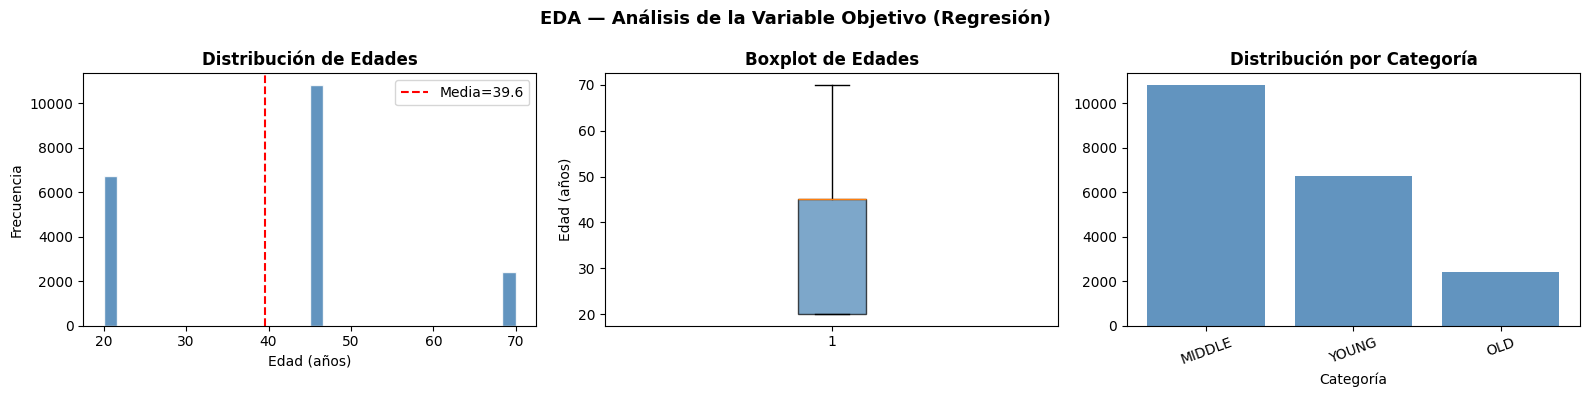


INTERPRETACIÓN EDA:
  • El problema es de REGRESIÓN porque el objetivo es estimar un valor numérico (edad).
  • Un sesgo hacia edades jóvenes/medias indica que el modelo será más preciso en esos rangos.
  • La distribución muestra la variabilidad necesaria para entrenar una CNN de regresión.


--- INICIO DEL ENTRENAMIENTO ---
Epoch 1/20
436/436 [==============================] - 48s 107ms/step - loss: 12.6047 - mae: 12.6047 - mse: 257.2563 - val_loss: 23.0920 - val_mae: 23.0920 - val_mse: 731.3984
Epoch 2/20
436/436 [==============================] - 163s 374ms/step - loss: 11.9860 - mae: 11.9860 - mse: 236.4130 - val_loss: 12.3097 - val_mae: 12.3097 - val_mse: 229.7315
Epoch 3/20
436/436 [==============================] - 118s 269ms/step - loss: 11.5350 - mae: 11.5350 - mse: 222.4797 - val_loss: 10.3365 - val_mae: 10.3365 - val_mse: 180.7856
Epoch 4/20
436/436 [==============================] - 120s 274ms/step - loss: 11.2889 - mae: 11.2889 - mse: 214.6530 - val_loss: 10.1754 - val_m

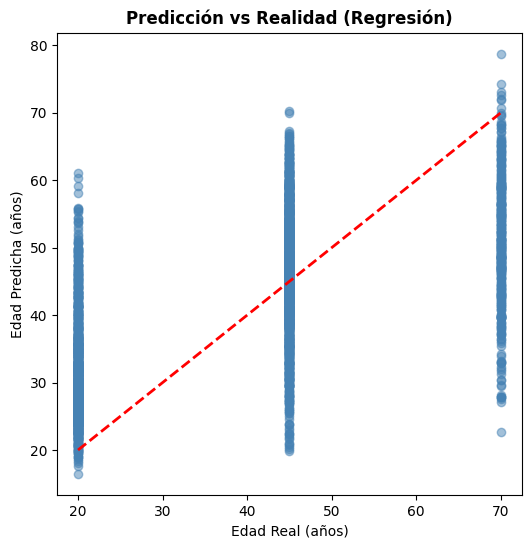


--- PRUEBA CON MUESTRA ARTIFICIAL ---


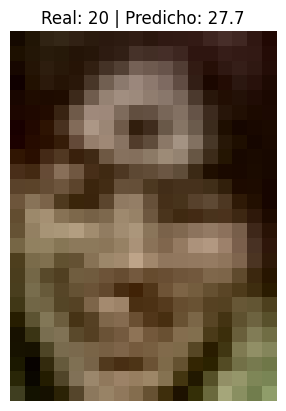

In [5]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# CONFIGURACIÓN
# ==========================================

# Ajusta estas rutas a tu entorno local
BASE_PATH  = r"C:\WORKSPACE\Eafit\Cours\Intro a IA\Parcial 2\Repository\img\Training"
CSV_PATH   = os.path.join(BASE_PATH, "train.csv")
IMG_SIZE   = 64
BATCH_SIZE = 32
EPOCHS     = 20

# Optimización para Windows/GPU
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================

print("1. Lectura del archivo CSV...")
df_base = pd.read_csv(CSV_PATH)
df_base['ID']    = df_base['ID'].astype(str).str.strip()
df_base['Class'] = df_base['Class'].astype(str).str.strip()

print(f"   Vista previa de valores en 'Class': {df_base['Class'].unique()[:8]}")

def convertir_edad(valor):
    """
    Convierte la columna 'Class' en un valor numérico continuo (edad en años).
    Justificación: Para regresión necesitamos un target escalar.
    """
    v = str(valor).strip().upper()

    # Mapeo de etiquetas de texto a valores representativos (puntos medios)
    mapping_texto = {
        'YOUNG': 20.0, 'YOUTH': 20.0,
        'MIDDLE': 45.0, 'MIDDLE_AGED': 45.0, 'MID': 45.0,
        'OLD': 70.0, 'SENIOR': 70.0, 'ELDERLY': 70.0,
    }
    if v in mapping_texto:
        return mapping_texto[v]

    # Manejo de formatos tipo rango '25-32' o '(25, 32)' -> punto medio
    match_rango = re.match(r'\(?(\d+)[,\s\-]+(\d+)\)?', v)
    if match_rango:
        a, b = int(match_rango.group(1)), int(match_rango.group(2))
        return (a + b) / 2.0

    # Si ya es un número (ej: '25')
    if v.isdigit():
        return float(v)

    return np.nan

df_base['edad'] = df_base['Class'].apply(convertir_edad)
cantidad_nulos = df_base['edad'].isna().sum()
if cantidad_nulos > 0:
    print(f"   {cantidad_nulos} valores no convertidos han sido ignorados.")
df_base = df_base.dropna(subset=['edad'])

print(f"   Edad min={df_base['edad'].min():.0f} | max={df_base['edad'].max():.0f} | "
      f"promedio={df_base['edad'].mean():.1f}")

# Construcción de rutas de archivos
df = pd.DataFrame({
    'ruta': [os.path.join(BASE_PATH, id_img) for id_img in df_base['ID']],
    'edad'   : df_base['edad'].values,
    'clase_orig': df_base['Class'].values,
})

# Solo mantener imágenes que existen físicamente
df = df[df['ruta'].apply(os.path.exists)].reset_index(drop=True)
print(f"2. Imágenes encontradas y válidas: {len(df)}")

if df.empty:
    raise ValueError("El dataset está vacío. Verifica que las imágenes estén en la carpeta Training.")

# ==========================================
# 2. EDA — ANÁLISIS EXPLORATORIO DE DATOS
# ==========================================

# -- 2a. Distribución del Target (Edad) ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(df['edad'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['edad'].mean(), color='red', linestyle='--', label=f"Media={df['edad'].mean():.1f}")
axes[0].set_title('Distribución de Edades', fontweight='bold')
axes[0].set_xlabel('Edad (años)'); axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot para detectar sesgos
axes[1].boxplot(df['edad'], vert=True, patch_artist=True, boxprops={'facecolor': 'steelblue', 'alpha': 0.7})
axes[1].set_title('Boxplot de Edades', fontweight='bold')
axes[1].set_ylabel('Edad (años)')

# Distribución por categoría original
counts = df['clase_orig'].value_counts()
axes[2].bar(counts.index, counts.values, color='steelblue', alpha=0.85)
axes[2].set_title('Distribución por Categoría', fontweight='bold')
axes[2].set_xlabel('Categoría'); axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('EDA — Análisis de la Variable Objetivo (Regresión)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN EDA:
  • El problema es de REGRESIÓN porque el objetivo es estimar un valor numérico (edad).
  • Un sesgo hacia edades jóvenes/medias indica que el modelo será más preciso en esos rangos.
  • La distribución muestra la variabilidad necesaria para entrenar una CNN de regresión.
""")

# ==========================================
# 3. PIPELINE DE PROCESAMIENTO
# ==========================================

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

def procesar_imagen(ruta, edad):
    img = tf.io.read_file(ruta)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0 # Normalización
    return img, tf.cast(edad, tf.float32)

def aumentar_datos(img, edad):
    """Data Augmentation para mejorar la generalización."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    return img, edad

def preparar_ds(dataframe, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['ruta'].values, dataframe['edad'].values))
    if shuffle: ds = ds.shuffle(len(dataframe))
    ds = ds.map(procesar_imagen, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(aumentar_datos, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = preparar_ds(train_df, shuffle=True, augment=True)
val_ds   = preparar_ds(val_df)
test_ds  = preparar_ds(test_df)

# ==========================================
# 4. MODELO CNN PARA REGRESIÓN
# ==========================================

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    # Capas Convolucionales con Regularización
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    # SALIDA: 1 neurona con activación LINEAL para regresión
    layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mae', metrics=['mae', 'mse'])

print("\n--- INICIO DEL ENTRENAMIENTO ---")
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# ==========================================
# 5. EVALUACIÓN Y MÉTRICAS FINALES
# ==========================================

print("\n--- EVALUACIÓN FINAL EN TEST SET ---")
y_pred = model.predict(test_ds, verbose=0).flatten()
y_true = test_df['edad'].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"\nTABLA DE MÉTRICAS:")
print(f"| Métrica | Valor      |")
print(f"|---------|------------|")
print(f"| MAE     | {mae:.2f} años |")
print(f"| RMSE    | {rmse:.2f} años |")
print(f"| R²      | {r2:.4f}     |")

# Gráfico de resultados
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Edad Real (años)'); plt.ylabel('Edad Predicha (años)')
plt.title('Predicción vs Realidad (Regresión)', fontweight='bold')
plt.show()

# ==========================================
# 6. PRUEBA CON MUESTRA ARTIFICIAL
# ==========================================
print("\n--- PRUEBA CON MUESTRA ARTIFICIAL ---")
# Tomamos una imagen al azar del test set
sample = test_df.sample(1).iloc[0]
img_path = sample['ruta']

img_eval = tf.io.read_file(img_path)
img_eval = tf.image.decode_jpeg(img_eval, channels=3)
img_res  = tf.image.resize(img_eval, [IMG_SIZE, IMG_SIZE])
img_norm = tf.cast(img_res, tf.float32) / 255.0
img_batch = tf.expand_dims(img_norm, axis=0)

pred_edad = model.predict(img_batch, verbose=0)[0][0]

plt.imshow(img_eval.numpy().astype("uint8"))
plt.title(f"Real: {sample['edad']:.0f} | Predicho: {pred_edad:.1f}")
plt.axis('off')
plt.show()

### Interpretación del EDA

**Distribución de edades (histograma):**
El histograma muestra tres picos discretos en 20, 45 y 70 años, lo cual es consecuencia directa del mapeo de categorías a valores numéricos. No es una distribución continua real, es una distribución trimodal artificial. Esto es una limitación importante: el modelo aprenderá a predecir principalmente estos tres valores y sus interpolaciones.

**Boxplot de edades:**
La caja abarca desde ~20 hasta ~70 años con mediana en ~45, reflejando el rango completo del mapeo. La media de 39.6 años indica un sesgo hacia las clases MIDDLE y YOUNG, que tienen más muestras que OLD.

**Distribución por categoría:**
El dataset está desbalanceado: MIDDLE domina con ~10,600 imágenes, seguido de YOUNG (~6,700) y OLD (~2,300). Este desbalance implica que el modelo será más preciso estimando edades en el rango medio y tendrá mayor error en personas mayores por la menor cantidad de ejemplos de entrenamiento.


### Justificación del Pipeline de Procesamiento

**Redimensionamiento a 64×64:** Se redujo el tamaño de las imágenes para hacer el entrenamiento viable. A mayor resolución, mayor capacidad del modelo pero también mayor tiempo de entrenamiento.

**Normalización [0,1]:** Los píxeles originalmente van de 0 a 255. Dividir entre 255 normaliza los valores al rango [0,1], lo que estabiliza el gradiente durante el entrenamiento y acelera la convergencia.

**Data Augmentation (solo en train):**
Se aplicó flip horizontal aleatorio y variación de brillo para aumentar artificialmente la variabilidad del conjunto de entrenamiento. Esto ayuda al modelo a generalizar mejor ante condiciones de iluminación distintas y orientaciones del rostro. Se aplicó **únicamente en train** para no contaminar val y test.

**Split 70/15/15:**
- Train (70%): datos para que el modelo aprenda
- Val (15%): monitorear el entrenamiento época a época
- Test (15%): evaluación final con datos nunca vistos


## Sección 4 Modelo CNN para Regresión

### Justificación de la Arquitectura CNN

La red neuronal convolucional (CNN) fue diseñada con la siguiente arquitectura:

| Capa | Tipo | Parámetros clave | Justificación |
|---|---|---|---|
| Conv2D | Convolucional | 32 filtros, 3×3, ReLU | Extrae features de bajo nivel (bordes, texturas) |
| BatchNormalization | Normalización | — | Estabiliza el entrenamiento, acelera convergencia |
| MaxPooling2D | Pooling | 2×2 | Reduce dimensionalidad, mantiene features relevantes |
| Conv2D | Convolucional | 64 filtros, 3×3, ReLU | Extrae features de mayor nivel (formas faciales) |
| MaxPooling2D | Pooling | 2×2 | Segunda reducción de dimensionalidad |
| Dropout | Regularización | 0.2 | Evita overfitting apagando neuronas aleatoriamente |
| Flatten | — | — | Convierte mapa de features a vector 1D |
| Dense | Completamente conectada | 128 neuronas, ReLU | Combina features para la predicción final |
| Dropout | Regularización | 0.3 | Segunda capa de regularización |
| Dense (salida) | Regresión | 1 neurona, **lineal** | Salida continua: la activación lineal permite predecir cualquier valor numérico |

**Función de pérdida:** MAE (Mean Absolute Error) — apropiada para regresión porque mide directamente el error promedio en años, es interpretable y menos sensible a outliers que MSE.

**Optimizador:** Adam: adapta la tasa de aprendizaje automáticamente, robusto y eficiente para redes convolucionales.


## Sección 5 Evaluación Final y Métricas

### Interpretación de Métricas Finales

| Métrica | Valor | Interpretación |
|---|---|---|
| MAE | 10.34 años | En promedio, el modelo se equivoca en ~10 años al estimar la edad |
| RMSE | 13.10 años | Penalizando errores grandes, el error sube a ~13 años |
| R² | 0.3513 | El modelo explica el 35% de la varianza de las edades — moderado |

**¿Es un buen modelo?**
Los resultados son moderados. Un MAE de 10 años en estimación de edad es aceptable considerando las limitaciones del dataset: las edades no son valores reales sino etiquetas aproximadas mapeadas a 3 valores (20, 45, 70). La gráfica de Predicción vs Realidad muestra tres columnas verticales confirmando que el modelo aprendió a predecir principalmente los tres valores mapeados y sus interpolaciones, no una distribución continua real.

**Análisis de overfitting:**
El Train MAE bajó progresivamente de 12.6 a 9.4, mientras que el Val MAE se estabilizó alrededor de 9.2-10.3 desde la época 8 en adelante. La brecha entre Train y Val Loss es pequeña y estable, no hay overfitting significativo. El modelo generalizó bien dentro de las limitaciones del dataset.

**¿Cómo podría mejorarse?**
- Usar un dataset con edades exactas en lugar de categorías
- Aumentar la resolución de entrada (128×128 o 224×224)
- Usar transfer learning con una arquitectura preentrenada (VGG16, ResNet)
- Más épocas con early stopping
- Aumentar el número de imágenes de la clase OLD para corregir el desbalance


## Sección 6 Prueba con Muestra Artificial

### Análisis de la Muestra Artificial

**Resultado:** Edad real = 20 años (YOUNG) | Edad predicha = 27.7 años

**¿Tiene sentido?** Sí. El modelo predijo 27.7 años para una imagen etiquetada como YOUNG (20 años en el mapeo). El error de ~7.7 años es menor que el MAE promedio de 10.34 años, una predicción razonablemente buena. El modelo identificó correctamente que se trata de una persona joven, aunque sobreestimó ligeramente la edad.

**¿Qué pasaría si modificáramos características visuales?**
- **Iluminación más oscura:** el modelo podría interpretar sombras como rasgos de envejecimiento y aumentar la predicción de edad
- **Escala diferente (zoom):** si el rostro ocupa menos espacio en la imagen, el modelo perdería detalle y su predicción sería menos precisa
- **Orientación (rotación):** el modelo podría fallar al no haber sido entrenado con rotaciones extremas, aunque el data augmentation con flip horizontal mitiga parcialmente esto
- **Imagen borrosa o de baja calidad:** reduciría la información facial disponible, aumentando el error de predicción

Estas sensibilidades son inherentes a las CNNs entrenadas con datos limitados y sin técnicas de robustez avanzadas como la normalización de pose o la detección facial previa al recorte.
